<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/iLogos/nsst.jpg" width="400" height="100">

# DEMI | NOVA SST

## Mecânica dos Sólidos I

## Torção de barras elásticas
## Torção de barras elásticas. Parte II
## Problema 5 <a name="PV125"></a>

A figura representa um tubo de aço ($E =$ 210 GPa, $\nu =$ 0.3, $\alpha = 12\times 10^{-6}$ /ºC) com 120 mm de diâmetro exterior e 100 mm de diâmetro interior. O tubo pode considerar-se encastrado nas duas extremidades, $A$ e $C$, que distam 5 m entre si, e está livre de tensões à temperatura ambiente de 20ºC. Quando em operação, o tubo transporta um fluido que o aquece até atingir a temperatura de 80 ºC enquanto que sobre a flange $B$ é aplicado um momento de torção $T = 20$ kN.m. Considere o ponto $P$ localizado na periferia do tubo e sobre o plano $xz$, a uma distância de 1 m da extremidade $C$ do cilindro.

[a)](#A) Escreva o tensor das tensões no ponto $P$ para o referencial indicado.

[b)](#B) Determine analiticamente as tensões principais e as direcções principais do estado de tensão nesse ponto.

[c)](#C) Verifique o resultado da alínea anterior utilizando o diagrama de Mohr.

[d)](#D) Calcule quais seriam as leituras de dois extensómetros colados no ponto $P$ e fazendo ângulos de $\pm 45^\circ$ com o eixo $x$.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au12/Au12_P005_i1.jpg"
width="300" height="220">


In [139]:
import numpy as np

# Dados
# unidades: m, Pa, N, ºC

E, v = 210.e9, 0.3
alpha = 12.*1e-6 # /ºC
ri, re = 50.*1e-3, 60.*1e-3

LAB, LBC = 2., .3

Ti, Tf = 20., 80.
DT = Tf-Ti

TB = 20.*1e3 # N.m

#### a) Escreva o tensor das tensões no ponto $P$ para o referencial indicado.<a name="A"></a> ([_enunciatum_](#PV125))

Comece-se por analisar o equilíbrio estático do veio quando submetido a um momento torsor externo, $T$, aplicado na secção $B$.

**Equilíbrio estático**

Devido ao encastramento dos extremos da viga, secções A e C, existirão momentos de torção de reação, $T_A$ e $T_C$ respetivamente. O sumatório dos momentos (sentido positivo o sentido anti-horário) permite concluir:

\begin{equation*}
T = T_A + T_C
\end{equation*}

Esta equação não tem solução única pelo que o problema é dito estaticamente indeterminado. Para a solução do problema é necessário considerar uma equação complementar pela análise geométrica da deformada do veio.

**Equação de compatibilidade de ângulos de torção**

A rotação relativa dos extremos do veio, $\phi_{A/C}$ é neste caso do encastramento em ambas as secções extremas:

\begin{equation*}
\phi_{A/C} = \phi_{A} - \phi_{C} = 0
\quad\wedge\quad
\phi_{B/A} \equiv \phi_{B}
\quad\wedge\quad
\phi_{B/C} \equiv \phi_{B}
\quad\wedge\quad
\phi_{B/A} = \phi_{B/C}
\end{equation*}

desenvolvendo,

\begin{equation*}
\frac{T_{AB}L_{AB}}{GJ} = \frac{T_{BC}L_{BC}}{GJ}
~\Leftrightarrow~
T_{AB} = \frac{L_{BC}}{L_{AB}}T_{BC}
\end{equation*}

O diagrama de momentos torsores é constante entre os troços $AB$ e $BC$. O momento de torção no troço $AB$ é constante e igual a $T_A$, enquanto que o momento torsor no troço $BC$ é constante e igual a $T_C$.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au12/Au12_P005_i2.jpg"
width="400" height="200">

Assim sendo, pode-se constuir o seguinte sistema de equações:

\begin{equation*}
\begin{cases}
T &= \, T_A + T_C \\
&\text{}\\
T_{A} &= \, \displaystyle\frac{L_{BC}}{L_{AB}}T_{C}
\end{cases}
~\Leftrightarrow~
\begin{cases}
T_{C}  &= \displaystyle\frac{2}{5}T \\
&\text{}\\
T_{A} &= \, \displaystyle\frac{3}{2}T_{C} = \frac{3}{5}T
\end{cases}
\end{equation*}

In [140]:
TC = 2/5*TB
print(f'TC  = {TC*1e-3:.2f} kN.m')

TA = 3/5*TB
print(f'TA  = {TA*1e-3:.2f} kN.m')

TC  = 8.00 kN.m
TA  = 12.00 kN.m


Conhecidas as reações em termos do momento torsor nas secções $A$ e $C$ é possível determinar o tensão de corte que ocorre no ponto $P$ na periferia do veio ao longo do tramo $BC$ a uma distância de 1 m de $C$. Neste tramo o momento torsor é igual a $T_{BC} = T_{C}$. A fórmula de torção permite escrever:

\begin{equation*}
\tau = \frac{T\rho}{J}
\end{equation*}

para o ponto $P$: $\rho = r_e$, e para um veio oco o momento polar de inércia de secção vem dado por:

\begin{equation*}
J = \frac{\pi}{2}(r_e^3-r_i^3)
\end{equation*}

In [141]:
J = np.pi/2*(re**4 - ri**4)
print(f'J = {J:.3e} m3')
tauPxz = TC*re/J
print(f'tau xz(P) = {tauPxz*1e-6:.3f} MPa')

J = 1.054e-05 m3
tau xz(P) = 45.541 MPa


- Esforços devidos à dilatação térmica

Pelo efeito de dilatação térmica o veio irá estar submetido a esforços axiais ao longo do seu veio. Pelo princípio de sobreposição, aplicado a problemas estaticamente indeterminados, comece-se por eliminar um dos encastramentos. Devido à expansão térmica o veio irá sofrer um alongamento (variação de comprimento) dado por:

\begin{equation*}
\delta^T = \alpha (\Delta T) L_{AC}
\end{equation*}

Para contrabalançar este alongamento do veio será introduzida uma força externa redundante. Esta força irá introduzir uma contração do veio dado por:

\begin{equation*}
\delta^F = \frac{FL_{AC}}{AE}
\end{equation*}

Pela compatibilidade de deslocamentos têm-se:

\begin{equation*}
\delta^T = \delta^F
~\Leftrightarrow~
\alpha (\Delta T) L_{AC} = \frac{FL_{AC}}{AE}
\end{equation*}

de onde se conclui que a força redundante (fisicamente representando uma força de reação nos encastramentos):

\begin{equation*}
F = \alpha (\Delta T) AE
\end{equation*}

E a tensão normal vem dada por:

\begin{equation*}
\sigma = \frac{F}{A} = \alpha (\Delta T) E
\end{equation*}

In [142]:
A = np.pi*(re**2-ri**2)
print(f'A = {A*1e-3:.3e} mm2')

F = alpha*DT*A*E
print(f'F = {F*1e-3:.2f} kN (compressão)')

Sxx = F/A
print(f'Sxx = {Sxx*1e-6:.2f} MPa (compressão)')

A = 3.456e-06 mm2
F = 522.51 kN (compressão)
Sxx = 151.20 MPa (compressão)


Desta forma, o tensor das tensões no ponto $P$ escreve-se por:

\begin{equation*}
\sigma_{ij} =
\begin{bmatrix}
\sigma_{xx} & 0 & \tau_{xz} \\
0 & 0 & 0 \\
\tau_{zx} & 0 & 0 \\
\end{bmatrix} =
\begin{bmatrix}
\alpha (\Delta T) E  & 0 & T_Cre/J \\
0 & 0 & 0 \\
T_Cre/J & 0 & 0 \\
\end{bmatrix}  =
\begin{bmatrix}
-151.20  & 0 & -45.54 \\
0 & 0 & 0 \\
-45.54 & 0 & 0 \\
\end{bmatrix} ~\text{MPa}
\end{equation*}

In [143]:
def tensortens(sxx,sxy,sxz,syy,syz,szz):
    return np.array([[sxx,sxy,sxz],[sxy,syy,syz],[sxz,syz,szz]])

tt0 = tensortens(-Sxx*1e-6,0,-tauPxz*1e-6,0,0,0) # unidades; MPa
print('tt0 = \n',tt0)

tt0 = 
 [[-151.2       0.      -45.5406]
 [   0.        0.        0.    ]
 [ -45.5406    0.        0.    ]]


#### b) Determine analiticamente as tensões principais e as direcções principais do estado de tensão nesse ponto.<a name="B"></a>([_enunciatum_](#PV125))

As tensões de corte são nulas em facetas que definem planos principais num dado ponto $P$ do corpo. Assim sendo, o vetor tensão que atua nesse ponto e segundo a normal exterior a essa faceta tem apenas uma componente normal:

\begin{equation*}
\vec{t}(P,\vec{n}) = t_x \vec{\imath} + t_y \vec{\jmath} + t_z \vec{k} = \sigma\,\vec{n}
\end{equation*}

em que $\sigma$ representa o módulo da tensão normal que atua na direção do versor $\vec{n}$. $\sigma$ é portanto uma tensão principal e a direção representada por $\vec{n}$ um eixo principal de tensão. As componentes do versor $\vec{n}$ no sistema de coordenadas $S(0,x,y,z)$ são dados pelos cosenos diretores:

\begin{array}{c|ccc}
& x & y & z \\\hline
n & l & m & n
\end{array}

pelo que: $\vec{n} = l \vec{\imath} + m \vec{\jmath} + n \vec{k}$. Desta forma, podem escrever-se as seguintes expressões escalares para as componentes cartesianas do vetor tensão $\vec{t}$:

\begin{equation*}
\begin{cases}
t_x = \sigma l \\
t_y = \sigma m \\
t_z = \sigma n \\
\end{cases}
\end{equation*}

Por outro lado, atendendo à fórmula de Cauchy:

\begin{equation*}
\vec{t}(P,\vec{n}) = \tilde{\sigma} \cdot \vec{n}~, \quad (\tilde{\sigma} = \tilde{\sigma}^T)
\end{equation*}

resulta a seguinte igualdade:

\begin{equation*}
\begin{aligned}
\tilde{\sigma} \cdot \vec{n} & = \sigma\,\vec{n} \\
(\sigma\tilde{I} - \tilde{\sigma})\cdot \vec{n} & = 0 \\
\end{aligned}
\end{equation*}

Este sistema tem as seguintes expressões escalares:

\begin{equation*}
\begin{cases}
l(\sigma-\sigma_{xx}) + m \tau_{xy} + n \tau_{xz} = 0 \\
l\tau_{xy} + m (\sigma-\sigma_{yy}) + n \tau_{yz} = 0 \\
l\tau_{xz} + m \tau_{yz} + n (\sigma-\sigma_{zz}) = 0
\end{cases}
\end{equation*}

A expressão anterior representa um sistema de equações lineares homogéneas na forma (notação indicial):

\begin{equation*}
\begin{aligned}
A_{ij} \cdot n_j & = 0~; \quad\text{com}\quad A_{ij} = \sigma\delta_{ij} - \sigma_{ij}\\
\end{aligned}
\end{equation*}

A solução trivial deste sistema de equações para o qual $n_j = 0$ ($l = m = n = 0$) não é possível porque $n_j\cdot n_j = 1$, ou seja, $l^2+m^2+n^2 = 1$. Surge da teoria da álgebra linear de sistemas de equações que a solução do sistema linear homogéneo só é possível se for nulo o determinante:

\begin{equation*}
\det(\sigma\delta_{ij} - \sigma_{ij})= 0
\end{equation*}

A solução desta expressão conduz a um polinómio cúbico caraterístico cujas raízes são os valores das três tensões principais:

\begin{equation*}
\det(\sigma_{ij}-\sigma\delta_{ij})= 0
\end{equation*}

cuja solução algebrica conduz ao seguinte polinómio caraterístico associado ao tensor das tensões:

\begin{equation*}
\sigma^3 - I_1\sigma^2 + I_2\sigma - I_3 = 0
\end{equation*}

em que $I_i$ ($i=1,2,3$) representam os invariantes do tensor das tensões. Os invariantes vêm expressos em função das componentes cartesianas de $\sigma_{ij}$ por:

\begin{equation*}
\begin{aligned}
I_1 &= \mathrm{Tr}(\sigma_{ij}) \\
I_2 &= \frac{1}{2}\left[ \mathrm{Tr}(\sigma_{ij})^2 - \mathrm{Tr}(\sigma_{ij}^2) \right] =
\frac{1}{2}\left( \sigma_{ii}\sigma_{jj} - \sigma_{ij}\sigma_{ji} \right) \\
& =
\begin{vmatrix}
\sigma_{11} & \sigma_{12} \\
\sigma_{21} & \sigma_{22} \\
\end{vmatrix} +
\begin{vmatrix}
\sigma_{11} & \sigma_{13} \\
\sigma_{31} & \sigma_{33} \\
\end{vmatrix} +
\begin{vmatrix}
\sigma_{22} & \sigma_{23} \\
\sigma_{32} & \sigma_{33} \\
\end{vmatrix} \\\\
I_3 &= \mathrm{det}(\sigma_{ij}) \\
\end{aligned}
\end{equation*}

Na prática porque a direção do eixo dos $y$ é direção principal de tensão e $\sigma_{yy} = 0 $ MPa é uma tensão principal, pode-se resolver a seguinte expressão (no plano $x-z$):

\begin{equation*}
|\sigma_{ij} - \sigma\delta_{ij}| = 0
\end{equation*}

desenvolvendo algebricamente,

\begin{equation*}
\begin{vmatrix}
\sigma_{xx} - \sigma & \sigma_{xz} \\
\sigma_{xz} & - \sigma
\end{vmatrix} = 0
~\Leftrightarrow~
(\sigma_{xx} - \sigma)(- \sigma) - \sigma_{xz}^2 = 0
~\Leftrightarrow~
\sigma^2 + 151,2\sigma - 45,5^2 = 0
\end{equation*}

In [144]:
print('\n Calculo dos invariantes pela matriz das tensões  : ..................')

I1 = np.trace(tt0)
print(f'1º Invariante, I1 : {I1:.1f}')

I2 = 0.5*(np.trace(tt0)**2 -np.trace(np.dot(tt0,tt0)))
print(f'2º Invariante, I2 : {I2:.1f}')

I3 = np.linalg.det(tt0)
print(f'3º Invariante, I3 : {I3:.1f}')

print('\n Resolucao Numerica - Numpy : ............................')
valpropriosN = np.roots([1,-I1,I2,-I3])
print('\n Roots = ',-np.sort(-valpropriosN))

sI = valpropriosN[1]
print(f'Tensão principal sI : {sI:.2f} MPa')
sII = valpropriosN[2]
print(f'Tensão principal sII : {sII:.2f} MPa')
sIII = valpropriosN[0]
print(f'Tensão principal sIII : {sIII:.2f} MPa')


 Calculo dos invariantes pela matriz das tensões  : ..................
1º Invariante, I1 : -151.2
2º Invariante, I2 : -2073.9
3º Invariante, I3 : 0.0

 Resolucao Numerica - Numpy : ............................

 Roots =  [  12.6571    0.     -163.8571]
Tensão principal sI : 12.66 MPa
Tensão principal sII : 0.00 MPa
Tensão principal sIII : -163.86 MPa


As direções principais de tensão são obtidas analitacamente pela resolução do seguinte sistema de equações:

\begin{equation*}
(\sigma_{ij} - \sigma_\alpha\delta_{ij})\cdot n_j = 0 \quad \wedge \quad n_i\cdot n_i = 1
\quad (\alpha = \mathrm{I,II,III})
\end{equation*}

In [145]:
from sympy.solvers import solve
from sympy import symbols

nx,ny,nz = symbols('nx ny nz')

def eq1(nx,ny,nz,vp): return (tt0[0,0] - vp)*nx + tt0[0,1]*ny + tt0[0,2]*nz
def eq2(nx,ny,nz,vp): return tt0[1,0]*nx + (tt0[1,1] - vp)*ny + tt0[1,2]*nz
def eq3(nx,ny,nz,vp): return tt0[2,0]*nx + tt0[2,1]*ny + (tt0[2,2] - vp)*nz
def eq4(nx,ny,nz): return nx**2 + ny**2 + nz**2 - 1

def versor(e1,e2,e3): return np.array([e1,e2,e3])

# 1 valor proprio -------------------
print('-------------------------------------------')
print('Vetor próprio associado a sI = ','{:.2f}'.format(sI),' MPa')
print('-------------------------------------------')
print('\n(i) sistema de equações:')
E1_sI = eq1(nx,ny,nz,sI); print(E1_sI,' = 0')
E2_sI = eq2(nx,ny,nz,sI); print(E2_sI,' = 0')
E3_sI = eq3(nx,ny,nz,sI); print(E3_sI,' = 0')
E4_sI = eq4(nx,ny,nz); print(E4_sI,' = 0')
VetProp1 = solve([E2_sI,E3_sI,E4_sI], [nx,ny,nz], dict=True)
l1 = float(VetProp1[1][nx])
m1 = float(VetProp1[1][ny])
n1 = float(VetProp1[1][nz])
versorI = versor(l1,m1,n1)
print(f'\n(ii) nI = {l1:.3f} i + {m1:.3f} j + {n1:.3f} k')

thetax0xP = np.rad2deg(np.arccos(l1))
print(f'thetax0xP = {thetax0xP:.3f} º')

-------------------------------------------
Vetor próprio associado a sI =  12.66  MPa
-------------------------------------------

(i) sistema de equações:
-163.857051429839*nx - 45.5406096477555*nz  = 0
-12.657051429839*ny  = 0
-45.5406096477555*nx - 12.657051429839*nz  = 0
nx**2 + ny**2 + nz**2 - 1  = 0

(ii) nI = 0.268 i + 0.000 j + -0.963 k
thetax0xP = 74.468 º


In [146]:
# 2 valor proprio -------------------
print('-------------------------------------------')
print('Vetor próprio associado a sI = ','{:.2f}'.format(sII),' MPa')
print('-------------------------------------------')
print('\n(i) sistema de equações:')
E1_sII = eq1(nx,ny,nz,sII); print(E1_sII,' = 0')
E2_sII = eq2(nx,ny,nz,sII); print(E2_sII,' = 0')
E3_sII = eq3(nx,ny,nz,sII); print(E3_sII,' = 0')
E4_sII = eq4(nx,ny,nz); print(E4_sII,' = 0')
VetProp2 = solve([E1_sII,E3_sII,E4_sII], [nx,ny,nz], dict=True)
l2 = float(VetProp2[1][nx])
m2 = float(VetProp2[1][ny])
n2 = float(VetProp2[1][nz])
versorII = versor(l2,m2,n2)
print(f'\n(ii) nII = {l2:.3f} i + {m2:.3f} j + {n2:.3f} k')

-------------------------------------------
Vetor próprio associado a sI =  0.00  MPa
-------------------------------------------

(i) sistema de equações:
-151.2*nx - 45.5406096477555*nz  = 0
0  = 0
-45.5406096477555*nx  = 0
nx**2 + ny**2 + nz**2 - 1  = 0

(ii) nII = 0.000 i + 1.000 j + 0.000 k


In [147]:
# 3 valor proprio -------------------
print('-------------------------------------------')
print('Vetor próprio associado a sIII = ','{:.2f}'.format(sIII),' MPa')
print('-------------------------------------------')
print('\n(i) sistema de equações:')
E1_sIII = eq1(nx,ny,nz,sIII); print(E1_sIII,' = 0')
E2_sIII = eq2(nx,ny,nz,sIII); print(E2_sIII,' = 0')
E3_sIII = eq3(nx,ny,nz,sIII); print(E3_sIII,' = 0')
E4_sIII = eq4(nx,ny,nz); print(E4_sIII,' = 0')
VetProp3 = solve([E1_sIII,E2_sIII,E4_sIII], [nx,ny,nz], dict=True)
l3 = float(VetProp3[1][nx])
m3 = float(VetProp3[1][ny])
n3 = float(VetProp3[1][nz])
versorIII = versor(l3,m3,n3)
print(f'\n(ii) nIII = ({l3:.3f}) i + ({m3:.3f}) j + ({n3:.3f}) k')

-------------------------------------------
Vetor próprio associado a sIII =  -163.86  MPa
-------------------------------------------

(i) sistema de equações:
12.657051429839*nx - 45.5406096477555*nz  = 0
163.857051429839*ny  = 0
-45.5406096477555*nx + 163.857051429839*nz  = 0
nx**2 + ny**2 + nz**2 - 1  = 0

(ii) nIII = (0.963) i + (0.000) j + (0.268) k


De notar que a solução algébrica do sistema de equações linear homogéneo conduz a soluções do tipo:

\begin{equation*}
\vec{n_\mathrm{I}} = \pm l_1 \vec{\imath} \pm m_1 \vec{\jmath} \pm n_1 \vec{k}
\end{equation*}

Para estabelecer a convenção de sinal deve-se incorporar informação sobre a física do problema. Neste contexto, os versores das direções principais devem formar entre si um sistema de coordenadas ortonormado e direto, ou seja, devem satisfazer as seguintes relações:

- Sistema ortonormado:

\begin{equation*}
\begin{aligned}
e_\mathrm{I} \cdot e_\mathrm{I} &=  1 \quad\wedge\quad
e_\mathrm{II} \cdot e_\mathrm{II} &=  1 \quad\wedge\quad
e_\mathrm{III} \cdot e_\mathrm{III} &=  1 \\
e_\mathrm{I} \cdot e_\mathrm{II} &=  0 \quad\wedge\quad
e_\mathrm{I} \cdot e_\mathrm{III} &=  0 \quad\wedge\quad
e_\mathrm{II} \cdot e_\mathrm{III} &=  0 \\
\end{aligned}
\end{equation*}

- Sistema direto (regra da mão direita da multiplicação de vetores)

\begin{equation*}
\begin{aligned}
e_\mathrm{I} \times e_\mathrm{II} &= e_\mathrm{III}\\
e_\mathrm{II} \times e_\mathrm{III} &= e_\mathrm{I} \\
e_\mathrm{III} \times e_\mathrm{I} &= e_\mathrm{II} \\
\end{aligned}
\end{equation*}

In [148]:
eI, eII, eIII = versorI, versorII, versorIII

print('\n Sistema de coordenadas ortonormado: ')
print(f'    dot(eI,eI) = {np.dot(eI,eI):.1f}')
print(f'  dot(eII,eII) = {np.dot(eII,eII):.1f}')
print(f'dot(eIII,eIII) = {np.dot(eIII,eIII):.1f}')
print(f'   dot(eI,eII) = {np.dot(eI,eII)}')
print(f' dot(eII,eIII) = {np.abs(np.dot(eII,eIII)):.1f}')
print(f'  dot(eI,eIII) = {np.dot(eI,eIII)}')


 Sistema de coordenadas ortonormado: 
    dot(eI,eI) = 1.0
  dot(eII,eII) = 1.0
dot(eIII,eIII) = 1.0
   dot(eI,eII) = 0.0
 dot(eII,eIII) = 0.0
  dot(eI,eIII) = 0.0


In [149]:

np.set_printoptions(precision=3)

print('\n Sistema de coordenadas direto (regra da mão direita da multiplicação de vetores): ')
print(' cross(eII,eIII) = ',np.abs(np.cross(eII,eIII)))
print(' cross(eIII,eI) = ',np.abs(np.cross(eIII,eI)))
print(' cross(eI,eII) = ',np.abs(np.cross(eI,eII)))

print('\n Matriz de transformação de S0 para SI (ref. principal): \n')

print(' Àngulo entre eI e x: ')
print(f' theta_P = {np.rad2deg(np.arccos(l1)):.2f} Deg')



 Sistema de coordenadas direto (regra da mão direita da multiplicação de vetores): 
 cross(eII,eIII) =  [0.268 0.    0.963]
 cross(eIII,eI) =  [0. 1. 0.]
 cross(eI,eII) =  [0.963 0.    0.268]

 Matriz de transformação de S0 para SI (ref. principal): 

 Àngulo entre eI e x: 
 theta_P = 74.47 Deg


In [150]:

np.set_printoptions(precision=4,suppress=True)

mT = np.concatenate((eI, eII,eIII))
mT = mT.reshape(3,3)
print('\n [T] = \n', mT)

print('\n[T][T]^T = I :\n',np.abs(np.dot(np.transpose(mT),mT)))

print(f'\n det(T) = {np.linalg.det(mT):.2f}')

ttp =  np.dot(mT,np.dot(tt0,np.transpose(mT)))
print('\n ttp = T tto T^T  = \n',ttp)


 [T] = 
 [[ 0.2678  0.     -0.9635]
 [ 0.      1.      0.    ]
 [ 0.9635  0.      0.2678]]

[T][T]^T = I :
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

 det(T) = 1.00

 ttp = T tto T^T  = 
 [[  12.6571    0.       -0.    ]
 [   0.        0.        0.    ]
 [  -0.        0.     -163.8571]]


<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au12/Au12_P005_i3.jpg"
width="500">

#### c) Verifique o resultado da alínea anterior utilizando o diagrama de Mohr.<a name="C"></a> ([_enunciatum_](#PV125))


PLANO x-z:
  Tensão normal mínima:  -163.86
  Tensão normal máxima:  12.66
  Tensão normal média :  -75.6
Tensão de corte mínima:  -88.26
Tensão de corte máxima:  88.26
Ponto X (-151.2,-45.5)
Ponto Z (0.0,45.5)


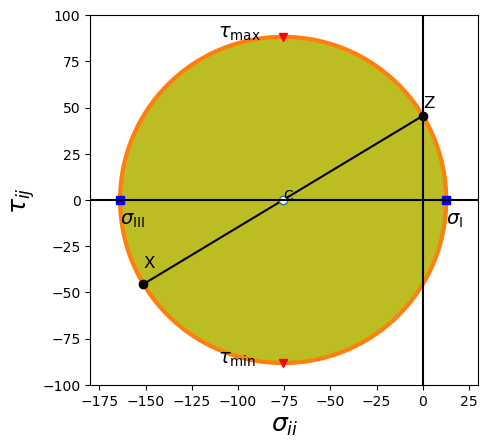


  Tensão principal I : 12.66 MPa
 Tensão principal II : 0.00 MPa
Tensão principal III : -163.86 MPa


In [151]:
import matplotlib.pyplot as plt

def mohr(S,limits):
    """Plot Mohr circle for a 2D tensor"""
    S11 = S[0][0]
    S12 = S[0][1]
    S22 = S[1][1]
    center = [(S11 + S22)/2.0, 0.0]
    radius = np.sqrt((S11 - S22)**2/4.0 + S12**2)
    Smin = center[0] - radius
    Smax = center[0] + radius

    print("  Tensão normal mínima: ", np.round(Smin,2))
    print("  Tensão normal máxima: ", np.round(Smax, 2))
    print("  Tensão normal média : ", np.round(center[0], 2))
    print("Tensão de corte mínima: ", np.round(-radius, 2))
    print("Tensão de corte máxima: ", np.round(radius, 2))
    print(f'Ponto X ({S11:.1f},{S12:.1f})')
    print(f'Ponto Z ({S22:.1f},{-S12:.1f})')

    circ = plt.Circle((center[0],0), radius, facecolor='tab:olive', lw=3,
    edgecolor='tab:orange')
    desv = 0.1*radius
    plt.axis('image')
    ax = plt.gca()
    ax.add_artist(circ)
    ax.set_xlim(Smin - .3*radius, Smax + .3*radius)
    ax.set_ylim(-1.3*radius, 1.3*radius)
    plt.plot([S11, S22], [S12, -S12], 'ko')
    plt.plot([S11, S22], [S12, -S12], 'k')
    plt.plot(Smin, 0, 'bs')
    plt.plot(Smax, 0, 'bs')
    plt.plot(center[0], radius, 'rv')
    plt.plot(center[0], -radius, 'rv')
    plt.plot(center[0], center[1], 'o', mfc='w')
    plt.text(center[0], 0, 'C')
    plt.text(S11, S12*.8, 'X',size=12)
    plt.text(S22, -S12*1.1, 'Z',size=12)
    plt.text(Smin, -0.15*radius, r'$\sigma_\mathrm{III}$',size=14)
    plt.text(Smax, -0.15*radius, r'$\sigma_\mathrm{I}$',size=14)
    plt.text(center[0]-4*desv, 1.*radius, r'$\tau_\mathrm{max}$',size=14)
    plt.text(center[0]-4*desv, -1.*radius, r'$\tau_\mathrm{min}$',size=14)
    plt.xlabel(r"$\sigma_{ii}$", size=18)
    plt.ylabel(r"$\tau_{ij}$", size=18)
    plt.xlim(limits[0,0],limits[0,1])
    plt.ylim(limits[1,0],limits[1,1])
    ax.axhline(y=0, color='k')
    ax.axvline(x=0, color='k')
    plt.show()

axislim = np.array([[-180,30],[-100,100]])
print('\n================================')
print('PLANO x-z:')
print('================================')
sxx, szz, sxz = tt0[0,0], tt0[2,2], tt0[0,2]
S = np.array([[sxx, sxz],[sxz, szz]])
mohr(S, axislim)

center = (sxx + szz)/2
radius = np.sqrt((sxx - szz)**2/4.0 + sxz**2)
smax = center + radius
smin = center - radius
print(f'\n  Tensão principal I : {smax:.2f} MPa')
print(f' Tensão principal II : {tt0[2,2]:.2f} MPa')
print(f'Tensão principal III : {smin:.2f} MPa')

#### d) Calcule quais seriam as leituras de dois extensómetros colados no ponto $P$ e fazendo ângulos de $\pm 45^\circ$ com o eixo $x$.<a name="D"></a> ([_enunciatum_](#PV125))

Para um estado plano de tensão, no plano $1-3$, para o qual se verifica: $\sigma_{22} = \tau_{21} = \tau_{23} = 0$, a lei de Hooke escreve-se:

\begin{equation*}
\begin{cases}
\varepsilon_{11} &= \frac{1}{E}(\sigma_{11} - \nu(\sigma_{33}) \\
\varepsilon_{33} &= \frac{1}{E}(\sigma_{33} - \nu(\sigma_{11}) \\
\gamma_{13} &=  \frac{\tau_{13}}{G}\\
\end{cases}
\end{equation*}

As leituras de extensómetros a $\pm 45^\circ$ são dadas por $\varepsilon_{11}$ e $\varepsilon_{33}$, respetivamente, de acordo com a equação constitutiva acima definida. Contudo é necessário previamente conhecer o estado de tensão no referência $\pm 45^\circ$, recorrendo às leis de transformação de um tensor de segunda ordem.

In [152]:
def Q(ang,rot):
    c, s = np.cos(ang), np.sin(ang)
    if rot == 1:
        Qij = np.array([[1,0,0],[0,c,s],[0,-s,c]])
    elif rot == 2:
        Qij = np.array([[c,0,s],[0,1,0],[-s,0,c]])
    else:
        Qij = np.array([[c,s,0],[-s,c,0],[0,0,1]])
    return Qij

a45 = np.deg2rad(45)
mt45 = Q(a45,2)

tt45 = np.dot(mt45,np.dot(tt0,np.transpose(mt45)))
print('\n tt45 =  \n',tt45)

print(f'\nsigma +45 = {tt45[0,0]:.2f} MPa')
print(f'sigma -45 = {tt45[2,2]:.2f} MPa')

# estado plano de tensão
sxx, szz = tt45[0,0], tt45[2,2]

E2 = E*1e-6 # unidades: MPa
ExTMais45 = (sxx - v*szz)/E2
print(f'ExTMais45 = {ExTMais45*1e6:.2f} microdef')
ExTMenos45 = (szz - v*sxx)/E2
print(f'ExTMenos45 = {ExTMenos45*1e6:.2f} microdef')


 tt45 =  
 [[-121.1406    0.       75.6   ]
 [   0.        0.        0.    ]
 [  75.6       0.      -30.0594]]

sigma +45 = -121.14 MPa
sigma -45 = -30.06 MPa
ExTMais45 = -533.92 microdef
ExTMenos45 = 29.92 microdef


---

Copyright (c) [Mecânica dos Sólidos I - DEMI - NOVA-SST]

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>
